# Week 12 — Fine‑Tuning, LoRA, & Integration
### *When do we update weights… and when should we avoid it?*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/finetuning_lecture.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

---

## Learning objectives
By the end of this notebook, you can:
- **Compare** prompting, RAG, and fine‑tuning as different ways to inject knowledge/behavior.
- **Explain** fine‑tuning as minimizing a loss over labeled examples (intuition + light math).
- **Describe** LoRA as a low‑rank weight update and **why** it reduces trainable parameters.
- **Recognize** overfitting and catastrophic forgetting, and propose mitigations (holdout eval, regularization, mixed data).
- **Design** an “adaptation plan” for a real app: what data you need, which metrics, and what failure modes.
- **Integrate** the full course system: UI → policy → retrieval/tools/agent → monitoring → evaluation → (optional) fine‑tune.

---

## Week flow
- **Tue (content):** drift observations from Lab 10/11 + Fine‑tuning vs prompting vs RAG + LoRA
- **Thu (content):** integration “how it all fits” + Lab 12: Fine‑tuning demo or plan


In [1]:
# @title 🔧 Setup (Run this first)
!git clone --depth 1 -q https://github.com/tulane-intro-ai-engineering/main.git
import sys, platform, random
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("/content/main")
from course_utils import show_mermaid, lab12_setup

lab12_setup()
random.seed(12)
np.random.seed(12)
print(f"✅ Environment ready! Python {platform.python_version()}")


installing mermaid-python
Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
installing dspy
✅ Environment ready! Python 3.12.12


---

# Day 1 (Tue) — Fine‑tuning vs prompting vs RAG

## **Warm‑up: drift observations (Lab 10/11)**
Take 5 minutes:
- What drift signal changed most in your experiment?
- Did drift correlate with a performance drop?
- What mitigation did you propose?

**We’ll use this to motivate fine‑tuning:**
Sometimes the *world* changes and we need the system to adapt.

---

## **Motivating success**
A support assistant learns your company’s tone and standard operating procedures:
- answers are consistent
- the assistant uses your preferred formatting
- it asks the right follow‑up questions

## **Motivating failure**
After “tuning,” it starts doing weird things:
- it becomes overly confident on topics outside your domain
- it forgets earlier safety rules (“catastrophic forgetting”)
- it learns a biased pattern from a small dataset

---

## **Guiding questions**
- When is prompting enough? When is RAG enough? When do we actually need fine‑tuning?
- What exactly changes during fine‑tuning?
- Why can fine‑tuning make things worse if done carelessly?


---

## **Three ways to change model behavior**
Let’s compare three knobs:

### 1) Prompting (including few‑shot examples)
You change the **input** to the model.

- ✅ fast to iterate
- ✅ no training infrastructure
- ✅ great for formatting, tone, small behavior changes
- ❌ brittle (prompt injection / prompt sensitivity)
- ❌ context window limits

### 2) RAG (retrieval augmented generation)
You change what **information** the model sees at runtime.

- ✅ keeps knowledge up‑to‑date
- ✅ citations and grounding possible
- ✅ easier to debug (“show me the source chunk”)
- ❌ retrieval can fail (recall@k issues)
- ❌ context limits: top‑k + chunking matter
- ❌ doesn’t directly “teach” a skill; it supplies evidence

### 3) Fine‑tuning (update weights)
You change the **model parameters**.

- ✅ strong for consistent style/format and domain patterns
- ✅ can reduce prompt length (cheaper at inference)
- ✅ can improve tool use patterns (in some setups)
- ❌ needs data + eval + training process
- ❌ risks overfitting / forgetting
- ❌ can be expensive (money + time + safety review)

---

### Reflection
> For each goal, choose the best knob (prompting / RAG / fine‑tuning):
> 1) “Use our brand voice.”  
> 2) “Answer with the newest policy.”  
> 3) “Always output valid JSON.”  
> 4) “Get better at a repeated classification task (like routing).”


In [2]:
# @title Visual: Decision sketch (not a rule, just a heuristic)
import pandas as pd

rows = [
    {"Goal":"New factual knowledge (changes often)", "Best first choice":"RAG"},
    {"Goal":"Format/tone/structure", "Best first choice":"Prompting"},
    {"Goal":"Shorter prompts / cheaper inference", "Best first choice":"Fine-tune (sometimes)"},
    {"Goal":"Repeated narrow task (routing, extraction)", "Best first choice":"Prompting → Fine-tune if stable"},
    {"Goal":"Citations/grounding needed", "Best first choice":"RAG (+ verification)"},
]
pd.DataFrame(rows)


,Goal,Best first choice
0,New factual knowledge (changes often),RAG
1,Format/tone/structure,Prompting
2,Shorter prompts / cheaper inference,Fine-tune (sometimes)
3,"Repeated narrow task (routing, extraction)",Prompting → Fine-tune if stable
4,Citations/grounding needed,RAG (+ verification)


---

## **Fine‑tuning in one sentence**
We choose model weights \( \theta \) that minimize loss on a dataset.

If we have examples \((x_i, y_i)\), then fine‑tuning tries to solve:

$$
\theta^* = \arg\min_\theta \ \frac{1}{n}\sum_{i=1}^n L(f_\theta(x_i), y_i)
$$

Where:
- $f_\theta$ is the model
- $x_i$ is an input (prompt, context, tool state)
- $y_i$ is the target output (answer, label, tool call, etc.)
- $L$ is a loss (how “wrong” the model is)

You don’t need the calculus details; the key is:
> Fine‑tuning nudges weights to make the model produce outputs like your dataset.

---

### Reflection
> If your dataset is biased or tiny, what direction do the weights get nudged?


---

## **Overfitting (intuitive)**
Overfitting happens when a model learns patterns that are “too specific” to your training set.

You often see:
- training loss ↓
- validation loss ↓ at first, then ↑ (worse generalization)

We’ll simulate this with a tiny toy model so the concept is concrete.


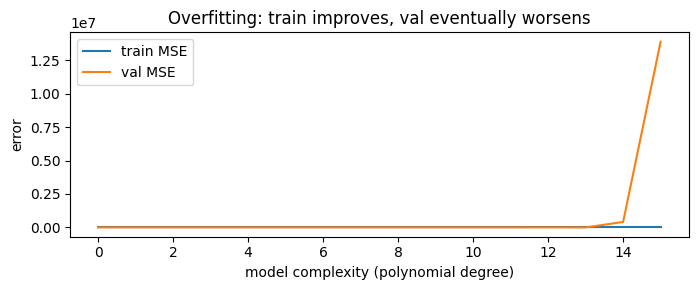

In [3]:
# @title Toy demo: train/val error pattern (simple polynomial fit)
# Not an LLM — just a clean visualization of overfitting.

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
x = np.linspace(-1, 1, 25)
y = np.sin(3*x) + 0.1*rng.normal(size=len(x))

# split
idx = np.arange(len(x))
rng.shuffle(idx)
train_idx = idx[:16]
val_idx = idx[16:]

x_tr, y_tr = x[train_idx], y[train_idx]
x_va, y_va = x[val_idx], y[val_idx]

def fit_poly(deg):
    Xtr = np.vstack([x_tr**k for k in range(deg+1)]).T
    Xva = np.vstack([x_va**k for k in range(deg+1)]).T
    w = np.linalg.lstsq(Xtr, y_tr, rcond=None)[0]
    tr_mse = ((Xtr @ w - y_tr)**2).mean()
    va_mse = ((Xva @ w - y_va)**2).mean()
    return tr_mse, va_mse

degrees = list(range(0, 16))
tr = []; va = []
for d in degrees:
    tr_mse, va_mse = fit_poly(d)
    tr.append(tr_mse); va.append(va_mse)

plt.figure(figsize=(7,3))
plt.plot(degrees, tr, label="train MSE")
plt.plot(degrees, va, label="val MSE")
plt.xlabel("model complexity (polynomial degree)")
plt.ylabel("error")
plt.title("Overfitting: train improves, val eventually worsens")
plt.legend()
plt.tight_layout()
plt.show()


### Reflection
> In LLM fine‑tuning, what might “model complexity” correspond to?
> (Hint: number of train steps, learning rate, or how narrow your dataset is.)


---

## **Catastrophic forgetting (intuitive)**
When we fine‑tune on narrow data, the model may “forget” general behaviors:
- safety refusals
- general reasoning style
- general knowledge patterns

**Why?** Gradients come from your narrow dataset and push weights away from the original model.

**Mitigations:**
- include a “mixture” of data (general + domain)
- use smaller learning rates / fewer steps
- evaluate on both: in‑domain and general safety tests
- consider LoRA/adapter methods (smaller updates)

---

### Reflection
> If you only fine‑tune on “company policy Q&A,” what general behavior might degrade?


---

# LoRA (Low‑Rank Adaptation)

## **What problem is LoRA solving?**
Full fine‑tuning updates *all* weights. That can be expensive and risky.

LoRA updates *a small number* of parameters by expressing the weight update as **low rank**.

---

## **The core idea**
Suppose a layer has weights $W \in R^{d \times k}$.

Instead of learning a full update $\Delta W$ (size $d \times k$),
LoRA learns:

$$
\Delta W \approx A B
$$

Where:
- $A \in R^{d \times r}$
- $B \in R^{r \times k}$
- $r$ is small (like 4, 8, 16)

Trainable parameters:
- full update: $d \cdot k$
- LoRA: $d \cdot r + r \cdot k$

---

### Reflection
> Why might “smaller updates” reduce the risk of catastrophic forgetting?


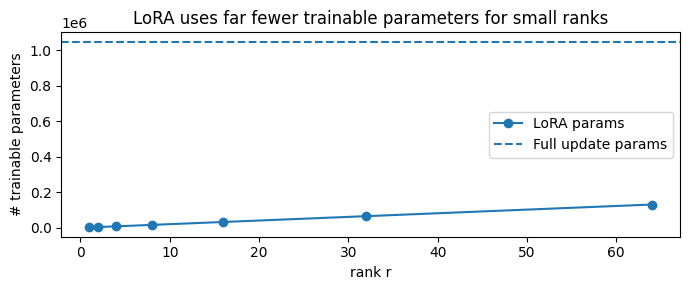

Full update params: 1048576
r= 1  LoRA params=    2048  (% of full=0.195%)
r= 2  LoRA params=    4096  (% of full=0.391%)
r= 4  LoRA params=    8192  (% of full=0.781%)
r= 8  LoRA params=   16384  (% of full=1.562%)
r=16  LoRA params=   32768  (% of full=3.125%)
r=32  LoRA params=   65536  (% of full=6.250%)
r=64  LoRA params=  131072  (% of full=12.500%)


In [4]:
# @title Visual: parameter counts for LoRA vs full update
import numpy as np
import matplotlib.pyplot as plt

d, k = 1024, 1024
full = d * k

rs = np.array([1, 2, 4, 8, 16, 32, 64])
lora = d * rs + rs * k

plt.figure(figsize=(7,3))
plt.plot(rs, lora, marker="o", label="LoRA params")
plt.axhline(full, linestyle="--", label="Full update params")
plt.xlabel("rank r")
plt.ylabel("# trainable parameters")
plt.title("LoRA uses far fewer trainable parameters for small ranks")
plt.legend()
plt.tight_layout()
plt.show()

print("Full update params:", full)
for r, p in zip(rs, lora):
    print(f"r={int(r):>2}  LoRA params={int(p):>8}  (% of full={p/full:.3%})")


---

## **LoRA as a “capacity knob”**
Rank \(r\) controls how expressive the update can be:
- very small \(r\): limited capacity → might underfit
- larger \(r\): more capacity → can fit more patterns (and possibly overfit)

---

### Reflection
> If your dataset is tiny, what happens if you choose a very large \(r\)?


---

# Day 2 (Thu) — Integration: mapping course concepts to a real stack

## **Unifying system (final)**
By now we’ve built pieces that look like an industry system:
- UI and routing
- safety checks / policy
- RAG retrieval
- tools and agent loops
- memory (agents II)
- monitoring & drift
- evaluation and metrics
- and now: adaptation (prompting, RAG, fine‑tuning)

Let’s put “fine‑tuning” into the unifying diagram.


In [5]:
# @title Unifying Diagram v9 (Mermaid): Fine-tuning added as an offline loop
mermaid = r'''
flowchart LR
  U[User] --> UI[UI / Gradio]
  UI --> API[App Router]
  API --> POL[Policy + Guardrails]
  POL --> PIPE[AI Pipeline]

  PIPE --> RAG[RAG Retrieve]
  RAG --> VDB[(Vector / Memory DB)]
  PIPE --> TOOLS[Tools/APIs]
  PIPE --> LLM[Base LLM]

  API --> LOGS[(Logs & Metrics)]
  LOGS --> EVAL[Eval Suite / Canary]
  EVAL --> ALERT[Alerts & Reports]

  subgraph OFFLINE[Offline Improvement Loop]
    DATA[Curated Training Data] --> FT[Fine-tune / LoRA]
    FT --> MODEL[Deployed Model Version]
  end

  MODEL --> API
  LOGS --> DATA

  classDef live fill:#eef,stroke:#335,color:#000;
  classDef obs fill:#fff7e6,stroke:#b7791f,color:#000;
  classDef off fill:#e8fff3,stroke:#2f855a,color:#000;

  class UI,API,POL,PIPE,RAG,TOOLS,LLM live;
  class LOGS,EVAL,ALERT obs;
  class OFFLINE,DATA,FT,MODEL off;
'''
show_mermaid(mermaid)


---

## **A practical “adaptation decision checklist”**
Before you fine‑tune, ask:

1) **Do we actually need weight updates?**
   - Can we solve with prompting?
   - Can we solve with RAG?
2) **Is the desired behavior stable?**
   - If policies change weekly, RAG is safer than fine‑tuning.
3) **Do we have enough good data?**
   - and do we have a holdout set that matches real usage?
4) **How will we measure improvement?**
   - metrics, human review, safety tests
5) **What could go wrong?**
   - overfitting, forgetting, safety regression, bias amplification
6) **How do we roll back?**
   - model versioning, canary release, monitoring

---

### Reflection
> Which checklist item is most likely to be skipped in a rushed startup?


---

## **Lab 12 preview: Fine‑tuning demo or plan**
In Lab 12 you will:
- run a mini LoRA intuition experiment (rank sweep)
- write a realistic adaptation plan for a GenAI system

This is the kind of workflow AI teams use constantly.


---

<details>
<summary><strong>Instructor Notes</strong></summary>

### Suggested pacing — Day 1 (50 min)
- 0–10: Drift observations discussion (students share what changed + mitigations)
- 10–20: Prompting vs RAG vs fine‑tuning comparison + reflection
- 20–30: Fine‑tuning loss intuition + overfitting concept
- 30–40: Toy overfitting plot + discussion; catastrophic forgetting + mitigations
- 40–50: LoRA intuition + parameter count figure

### Suggested pacing — Day 2 (50 min)
- 0–10: Recap + “when NOT to fine‑tune”
- 10–20: Unifying diagram update v9 (offline loop added)
- 20–30: Adaptation checklist + case study prompts
- 30–50: Lab 12 kickoff (students start Part A; outline Part B plan)

### Optional extensions
- Safety regression tests as a “gate” for fine‑tuned releases
- Data governance: labeling guidelines + privacy
- Why many teams prefer “RAG + good prompting” before fine‑tuning

</details>
